In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.optimize import curve_fit
from scipy.ndimage import shift as ndi_shift
from uncertainties import ufloat
from tqdm import tqdm

In [3]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [27]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4.0                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
alpha = np.arcsin(num_apt / n)

#10 microns
L_ffp = 8.11 * 1e-3
grid_ffp = 512
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
L_bfp = 2 * focal * num_apt #(lambd * focal * grid_bfp) / (10*L_ffp)
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

bead_radius = 0.0005
image_obj = Bead_Image(grid, [0], [0], [bead_radius])

wvft_1_mn = [[2, 2], [0, 4]]
wvft_1_coef = [0.2, 0.2]

wvft_3_mn = [[-1, 3], [-2, 2]]
wvft_3_coef = [0.2, 0.2]

wvft_6_mn = [[-1, 3], [2, 2], [0, 4]]
wvft_6_coef = [-0.2, -0.2, 0.2]

aberrations = [
    wvft_1_mn,
    wvft_3_mn,
    wvft_6_mn,
]

coefs = [
    wvft_1_coef,
    wvft_3_coef,
    wvft_6_coef,
]

aberration_dir = {
    1 : Aberration(wvft_1_mn, wvft_1_coef),
    3 : Aberration(wvft_3_mn, wvft_3_coef),
    6 : Aberration(wvft_6_mn, wvft_6_coef),
}

In [5]:
#produce a 3D fluorobead stack 

def three_d_img(microscope,
                     grid,
                     aberration,
                     num_slices,
                     z_camera,
                     bead_radius = 0.0005,
                     mode = "vector",
                     norm = False):

    z_levels = np.linspace(-bead_radius, bead_radius, num_slices)
    x, y = grid.get_xy()
    x_grid, y_grid, z_grid = np.meshgrid(x, y, z_levels, indexing="xy")
    three_d_bead_img = np.zeros_like(x_grid)
    three_d_bead_img[x_grid**2 + y_grid**2 + z_grid**2 <= bead_radius**2] = 1
    
    total_img = np.zeros_like(three_d_bead_img[:, :, 0])

    dz = z_levels[1] - z_levels[0]

    for i, img_z_level in enumerate(z_levels):
        grid.z_level = (z_camera - img_z_level)
        _, _, psf = microscope.compute_PSF(grid, aberration, mode = mode)
        img_contribution = psf_convolve(three_d_bead_img[:, :, i], psf, norm = norm)

        total_img += img_contribution * dz

    return x, y, total_img

In [6]:
from pathlib import Path
from PIL import Image

def get_trial_dictionary(trial: int):
    trial_name = "abb_" + str(trial)

    all_files = [f.name for f in Path('05_22_2026_data').iterdir() if f.is_file()]

    files = [f for f in all_files if trial_name in f]
    z_levels = [float(f[8:11].replace("p", ".")) for f in files]

    dir = dict(zip(z_levels, files))
    return dir

def extract_power(file_name: str):
    return float(file_name[16:19].replace("p", "."))

def get_z_levels(trial: int):
    dir = get_trial_dictionary(trial)
    z_levels = list(dir)
    z_levels.sort()
    return z_levels

#gets images, normalizing them by the power
def exp_image_stack(trial: int):
    z_levels = get_z_levels(trial)
    dir = get_trial_dictionary(trial)

    img_stack = []
    powers = []
    for z_level in z_levels:
        file_name = dir[z_level]
        power = extract_power(file_name)
        img = np.asarray(Image.open("05_22_2026_data/" + file_name))
        img_stack.append(img)
        powers.append(power)

    img_stack = np.array(img_stack)
    powers = np.array(powers)
    #ensure positivity of all of the images
    img_stack = img_stack - np.min(img_stack)
    #scale each of the images by its power
    img_stack = np.array([img_stack[i]/powers[i]**3 for i in range(len(img_stack))])
    #normalize by the brightest image in the array
    img_stack = (img_stack - np.min(img_stack)) / (np.max(img_stack) - np.min(img_stack))

    return z_levels, img_stack


import numpy as np
from scipy.ndimage import center_of_mass, shift

def align_com(img):
    shape = img.shape
    center = np.array([(s - 1) / 2 for s in shape])

    def shift_to_center(img):
        total = np.sum(img)

        if total == 0:
            return img.copy()

        com = np.array(center_of_mass(img))
        shift_vec = center - com

        return shift(
            img,
            shift=shift_vec,
            order=1,          # linear interpolation
            mode="constant",
            cval=0.0,
            prefilter=False
        )

    img_aligned = shift_to_center(img)

    return img_aligned

    

In [7]:
def sim_img_stack(trial,
                       microscope,
                       img_mask,
                       mode = "vector",
                       norm = False,
                       offset = 0):
    z_levels = get_z_levels(trial)
    aberration = aberration_dir[trial]

    img_stack = []
    for z_level in z_levels:
        x, y, img = three_d_img(microscope, img_mask, aberration, 21, (z_level + offset) * 1e-3, mode = mode, norm = norm)
        #microscope.compute_image(img_mask, aberration, mode, norm)
        img_stack.append(img)

    img_stack = np.array(img_stack)
    #normalize
    img_stack = (img_stack - np.min(img_stack)) / (np.max(img_stack) - np.min(img_stack))

    return z_levels, x, y, img_stack



In [8]:
from PIL import Image
import glob

In [9]:
def produce_gif(trial):
    z_levels, exp_img_stack = exp_image_stack(trial)
    z_levels, x, y, vector_img_stack = sim_img_stack(trial, microscope, image_obj, mode = "vector", norm = False)
    z_levels, x, y, scalar_img_stack = sim_img_stack(trial, microscope, image_obj, mode = "scalar", norm = False)

    print("Finished grabbing images and simulating")
    x = x * 1000
    y = y * 1000

    ticks = [-2.5, 0, 2.5]
    for i, z_level in tqdm(enumerate(z_levels)):

        exp_img = exp_img_stack[i]
        vector_img = vector_img_stack[i]
        scalar_img = scalar_img_stack[i]

         

        fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, layout = "tight",
                            figsize = (7, 3))
        axs[0].imshow(exp_img,
                extent=[x[0], x[-1], y[0], y[-1]],
                aspect = "equal",
                origin='lower')
        axs[0].grid(False)
        

        axs[1].imshow(vector_img,
                extent=[x[0], x[-1], y[0], y[-1]],
                aspect = "equal",
                origin='lower')
        axs[1].grid(False)

        axs[2].imshow(scalar_img,
                    extent=[x[0], x[-1], y[0], y[-1]],
                    aspect = "equal",
                    origin='lower')
        axs[2].grid(False)

        axs[0].set_xlabel("x [microns]")
        axs[1].set_xlabel("x [microns]")
        axs[2].set_xlabel("x [microns]")
        axs[0].set_ylabel("y [microns]")

        axs[0].set_title(f"Experimental")
        axs[1].set_title(f"Vector Optics")
        axs[2].set_title(f"Scalar Optics")

        for ax in axs:
            ax.set_xticks(ticks)
            ax.set_yticks(ticks)

        fig.suptitle(f"Comparison at z = {np.round(z_level, 1)} microns")
        plt.savefig(f"figures/trial{trial}/z_{np.round(z_level, 1)}.png", bbox_inches = "tight")
        plt.close()

    print("Finished making figures")

    frames = []
    imgs = sorted(glob.glob(f"figures/trial{trial}/*.png"))

    for i in imgs:
        new_frame = Image.open(i)
        frames.append(new_frame)
    frames[0].save(f"ab_{trial}.gif", format='GIF',
                append_images=frames[1:],
                save_all=True,
                duration=150, loop=0)

    print("Finished gif")


In [327]:
produce_gif(1)
produce_gif(3)
produce_gif(6)

Finished grabbing images and simulating


26it [00:08,  3.18it/s]


Finished making figures
Finished gif
Finished grabbing images and simulating


21it [00:08,  2.37it/s]


Finished making figures
Finished gif
Finished grabbing images and simulating


21it [00:06,  3.29it/s]


Finished making figures
Finished gif


In [10]:
def stack_brightness(img_stack, percentile):
    return np.array([np.percentile(img.flatten(), percentile) for img in img_stack])

def max_stack_brightness(img_stack, percentile):
    return np.max(stack_brightness(img_stack, percentile))

def norm_stack_brightness(img_stack, percentile):
    return stack_brightness(img_stack, percentile) / max_stack_brightness(img_stack, percentile)

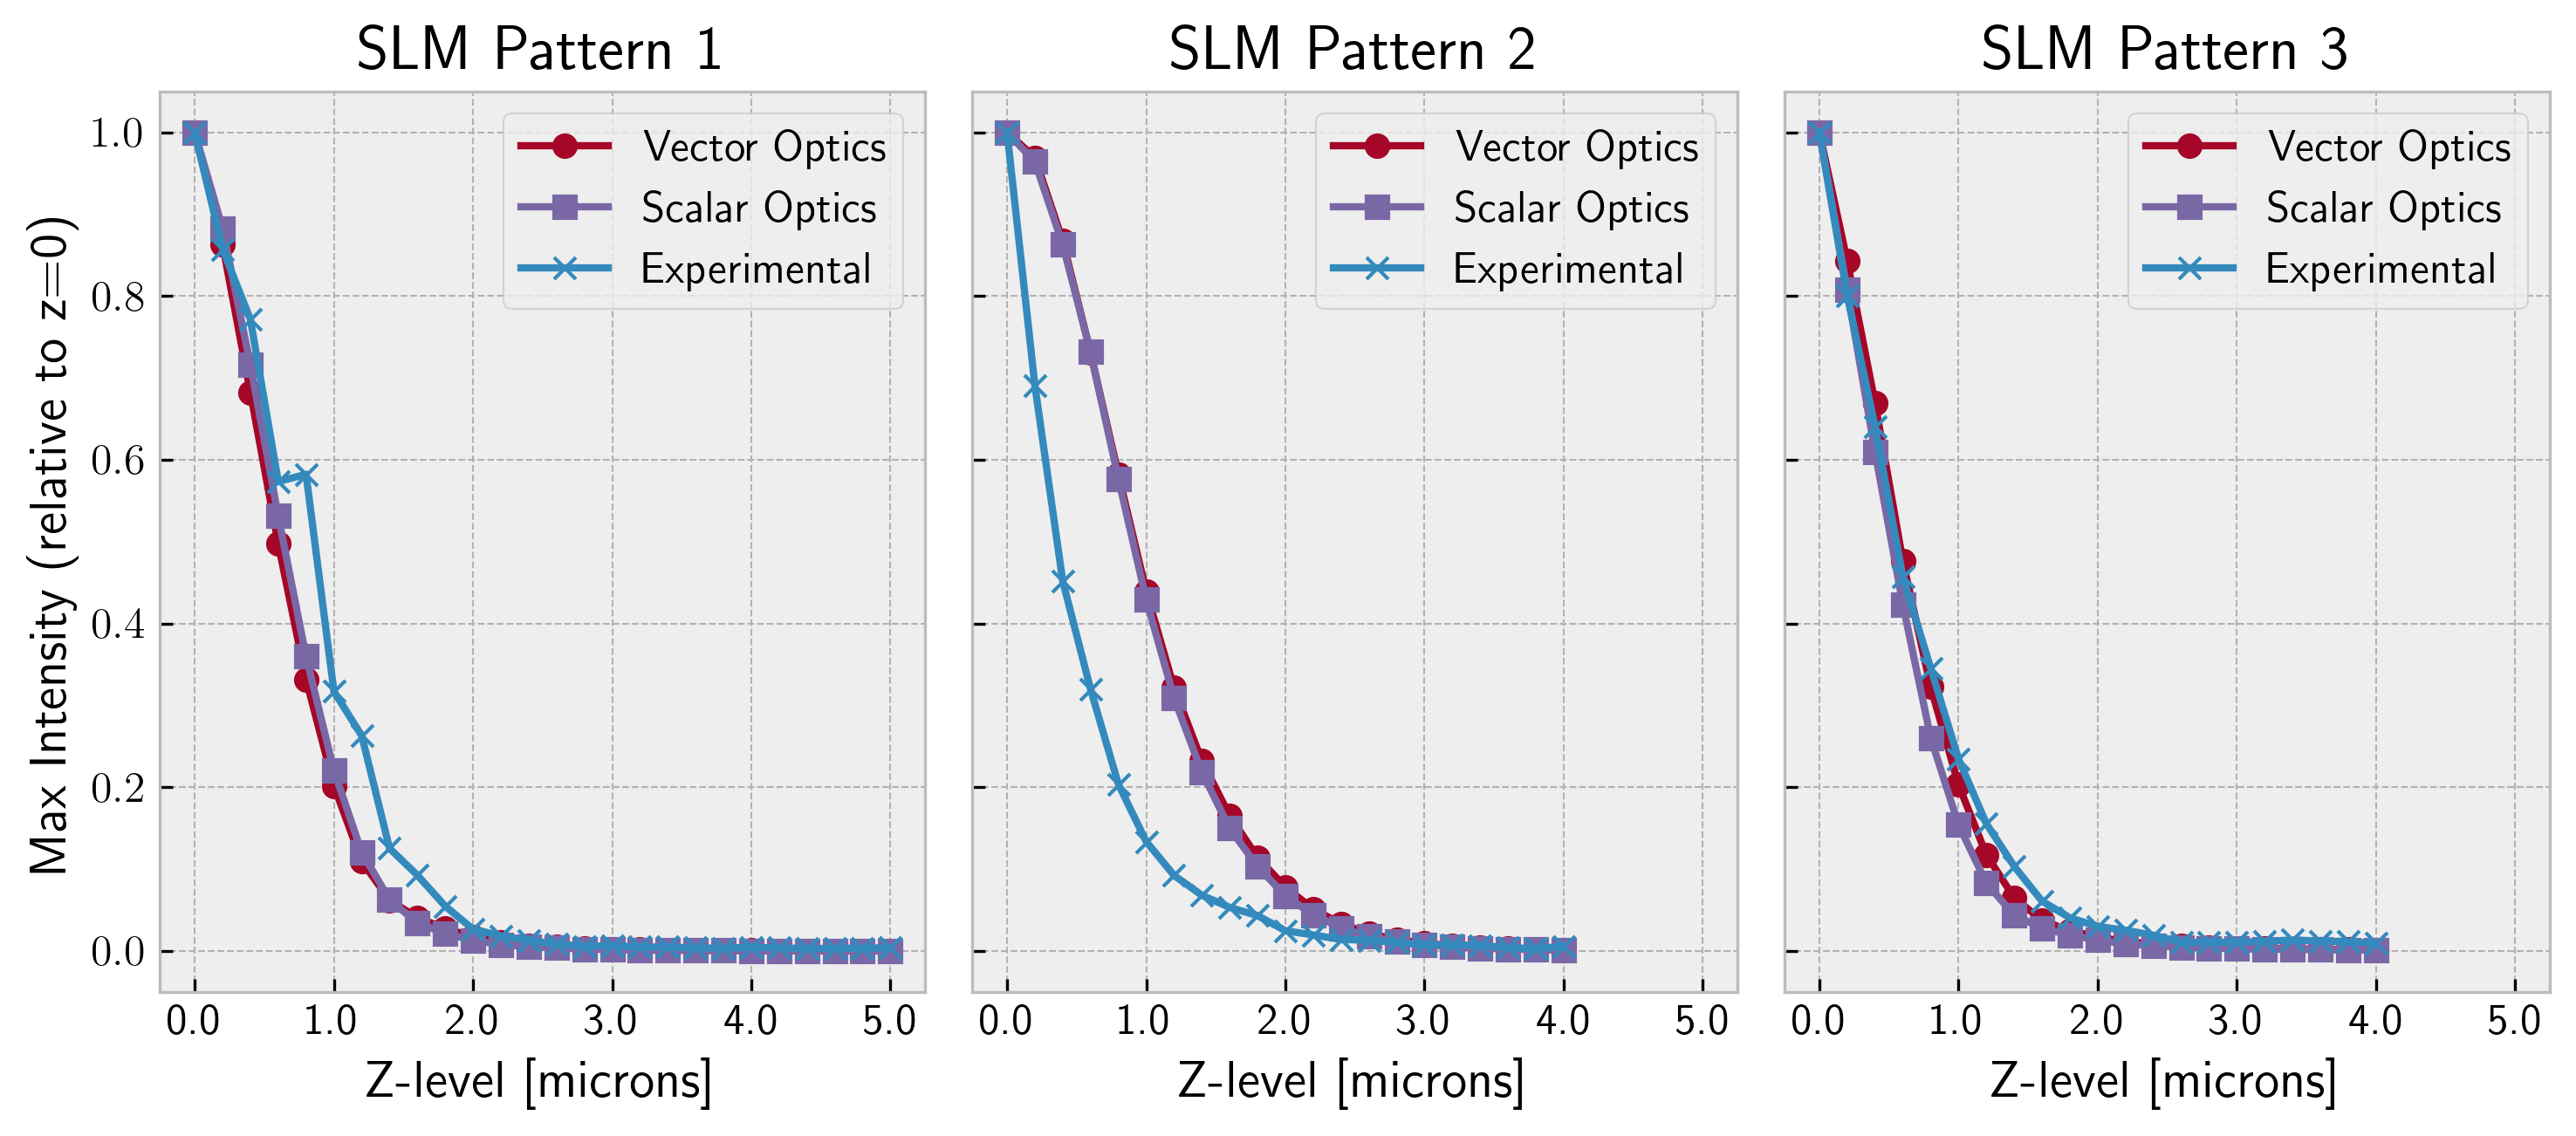

In [11]:
fig, axs = plt.subplots(1, 3, sharex = True, sharey = True, layout = "tight",
                            figsize = (10, 4.5))

axs[0].set_ylabel("Max Intensity (relative to z=0)")
#top 0.5 percent of pixels
p = 99.5
for i, trial in enumerate([1, 3, 6]):
    z_levels, exp_img_stack = exp_image_stack(trial)
    z_levels, x, y, vector_img_stack = sim_img_stack(trial, microscope, image_obj, "vector", norm = False)
    z_levels, x, y, scalar_img_stack  = sim_img_stack(trial, microscope, image_obj, "scalar", norm = False)

    axs[i].errorbar(z_levels, norm_stack_brightness(exp_img_stack, p), label = "Experimental", marker = "x")

    axs[i].plot(z_levels, norm_stack_brightness(vector_img_stack, p), label = "Vector Optics", marker = "o")

    axs[i].plot(z_levels, norm_stack_brightness(scalar_img_stack, p), label = "Scalar Optics", marker = "s")

    axs[i].set_xlabel("Z-level [microns]")
    axs[i].set_title(f"SLM Pattern {i+1}")
    axs[i].legend()
    axs[i].set_xticks([0.0, 1.0, 2.0, 3.0, 4.0, 5.0], ["0.0", "1.0", "2.0", "3.0", "4.0", "5.0"])
plt.savefig("axial_brightness.png")

In [12]:
trial = 1

def cross_section_plots(trial):
    z_levels, exp_img_stack = exp_image_stack(trial)
    z_levels, x, y, vector_img_stack = sim_img_stack(trial, microscope, image_obj, "vector", norm = False)
    z_levels, x, y, scalar_img_stack  = sim_img_stack(trial, microscope, image_obj, "scalar", norm = False)

    fig, axs = plt.subplots(2, 3, sharex = True, sharey = True,  figsize = (8, 5))

    #xz
    axs[0,0].set_title("Experimental XZ")
    axs[0, 0].imshow(exp_img_stack[:, 64, :], norm = "log",
                    extent=[x[0] * 1e3, x[-1] * 1e3, z_levels[0], z_levels[-1]],
                    aspect = "equal",
                    origin = "lower")

    axs[0,0].set_ylabel("z [microns]")
    axs[0,0].set_xlabel("x [microns]")


    #xz
    axs[0,1].set_title("Vector Optics XZ")
    axs[0, 1].imshow(vector_img_stack[:,  64, :], norm = "log",
                    extent=[x[0] * 1e3, x[-1] * 1e3, z_levels[0], z_levels[-1]],
                    aspect = "equal",
                    origin = "lower")
    axs[0,1].set_xlabel("x [microns]")

    #xz
    axs[0,2].set_title("Scalar Optics XZ")
    axs[0, 2].imshow(scalar_img_stack[:, 64, :], norm = "log",
                    extent=[x[0] * 1e3, x[-1] * 1e3, z_levels[0], z_levels[-1]],
                    aspect = "equal",
                    origin = "lower")
    axs[0,2].set_xlabel("x [microns]")

    #yz
    axs[1,0].set_title("Experimental YZ")
    axs[1, 0].imshow(exp_img_stack[:, :, 64], norm = "log",
                    extent=[y[0] * 1e3, y[-1] * 1e3, z_levels[0], z_levels[-1]],
                    aspect = "equal",
                    origin = "lower")
                    

    axs[1,0].set_ylabel("z [microns]")
    axs[1,0].set_xlabel("y [microns]")
    #yz
    axs[1,1].set_title("Vector Optics YZ")
    axs[1, 1].imshow(vector_img_stack[:, :, 64], norm = "log",
                    extent=[y[0] * 1e3, y[-1] * 1e3, z_levels[0], z_levels[-1]],
                    aspect = "equal",
                    origin = "lower")
    axs[1,1].set_xlabel("y [microns]")
    #yz
    axs[1,2].set_title("Scalar Optics YZ")
    axs[1, 2].imshow(scalar_img_stack[:, :, 64], norm = "log",
                    extent=[y[0] * 1e3, y[-1] * 1e3, z_levels[0], z_levels[-1]],
                    aspect = "equal",
                    origin = "lower")
    axs[1,2].set_xlabel("y [microns]")

    axs = axs.flatten()
    for ax in axs:
        ax.grid(False)

    plt.savefig(f"cross_sections_trial{trial}.png")

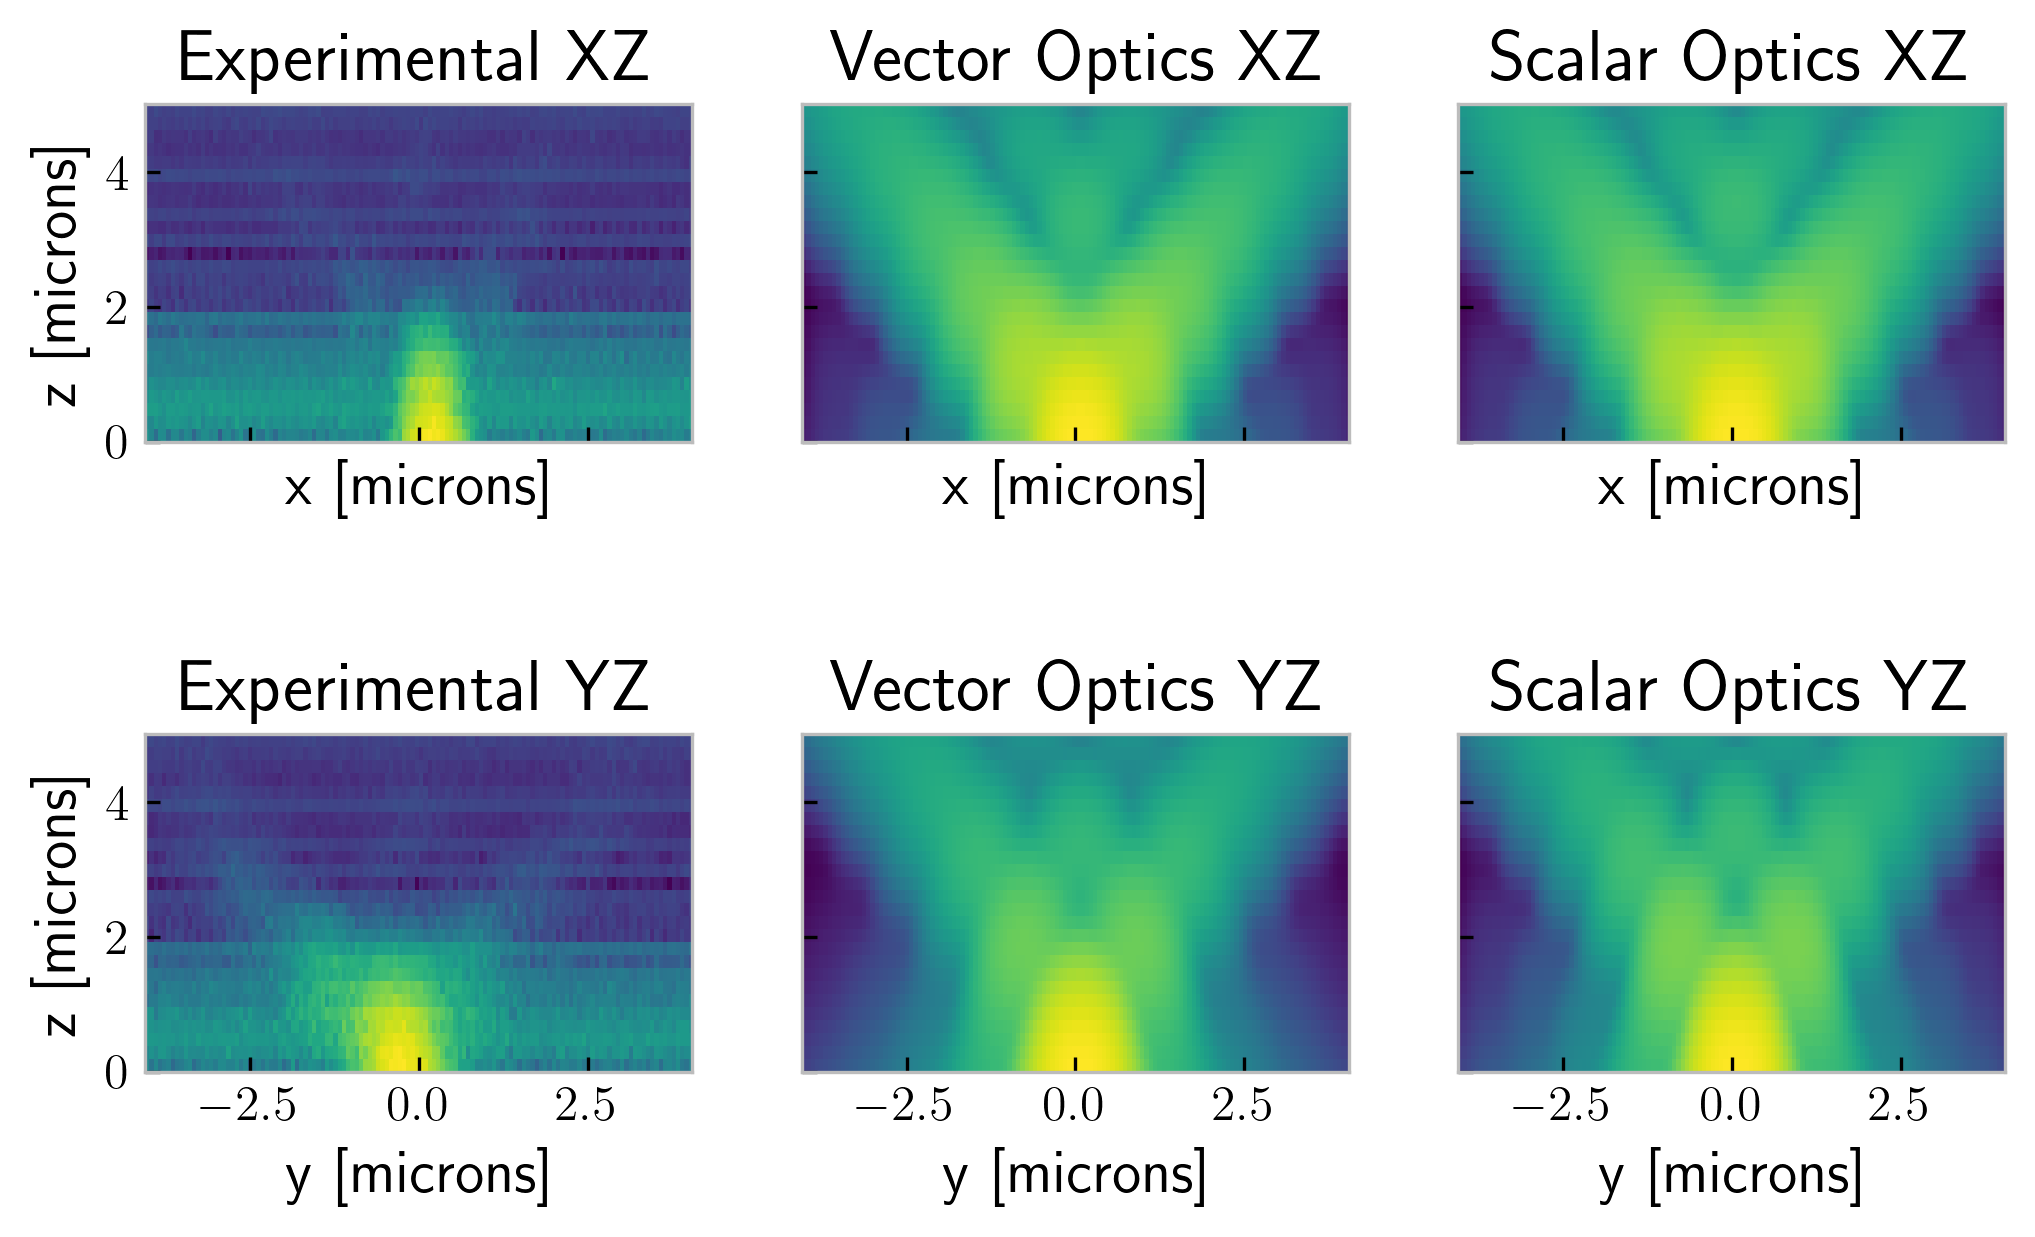

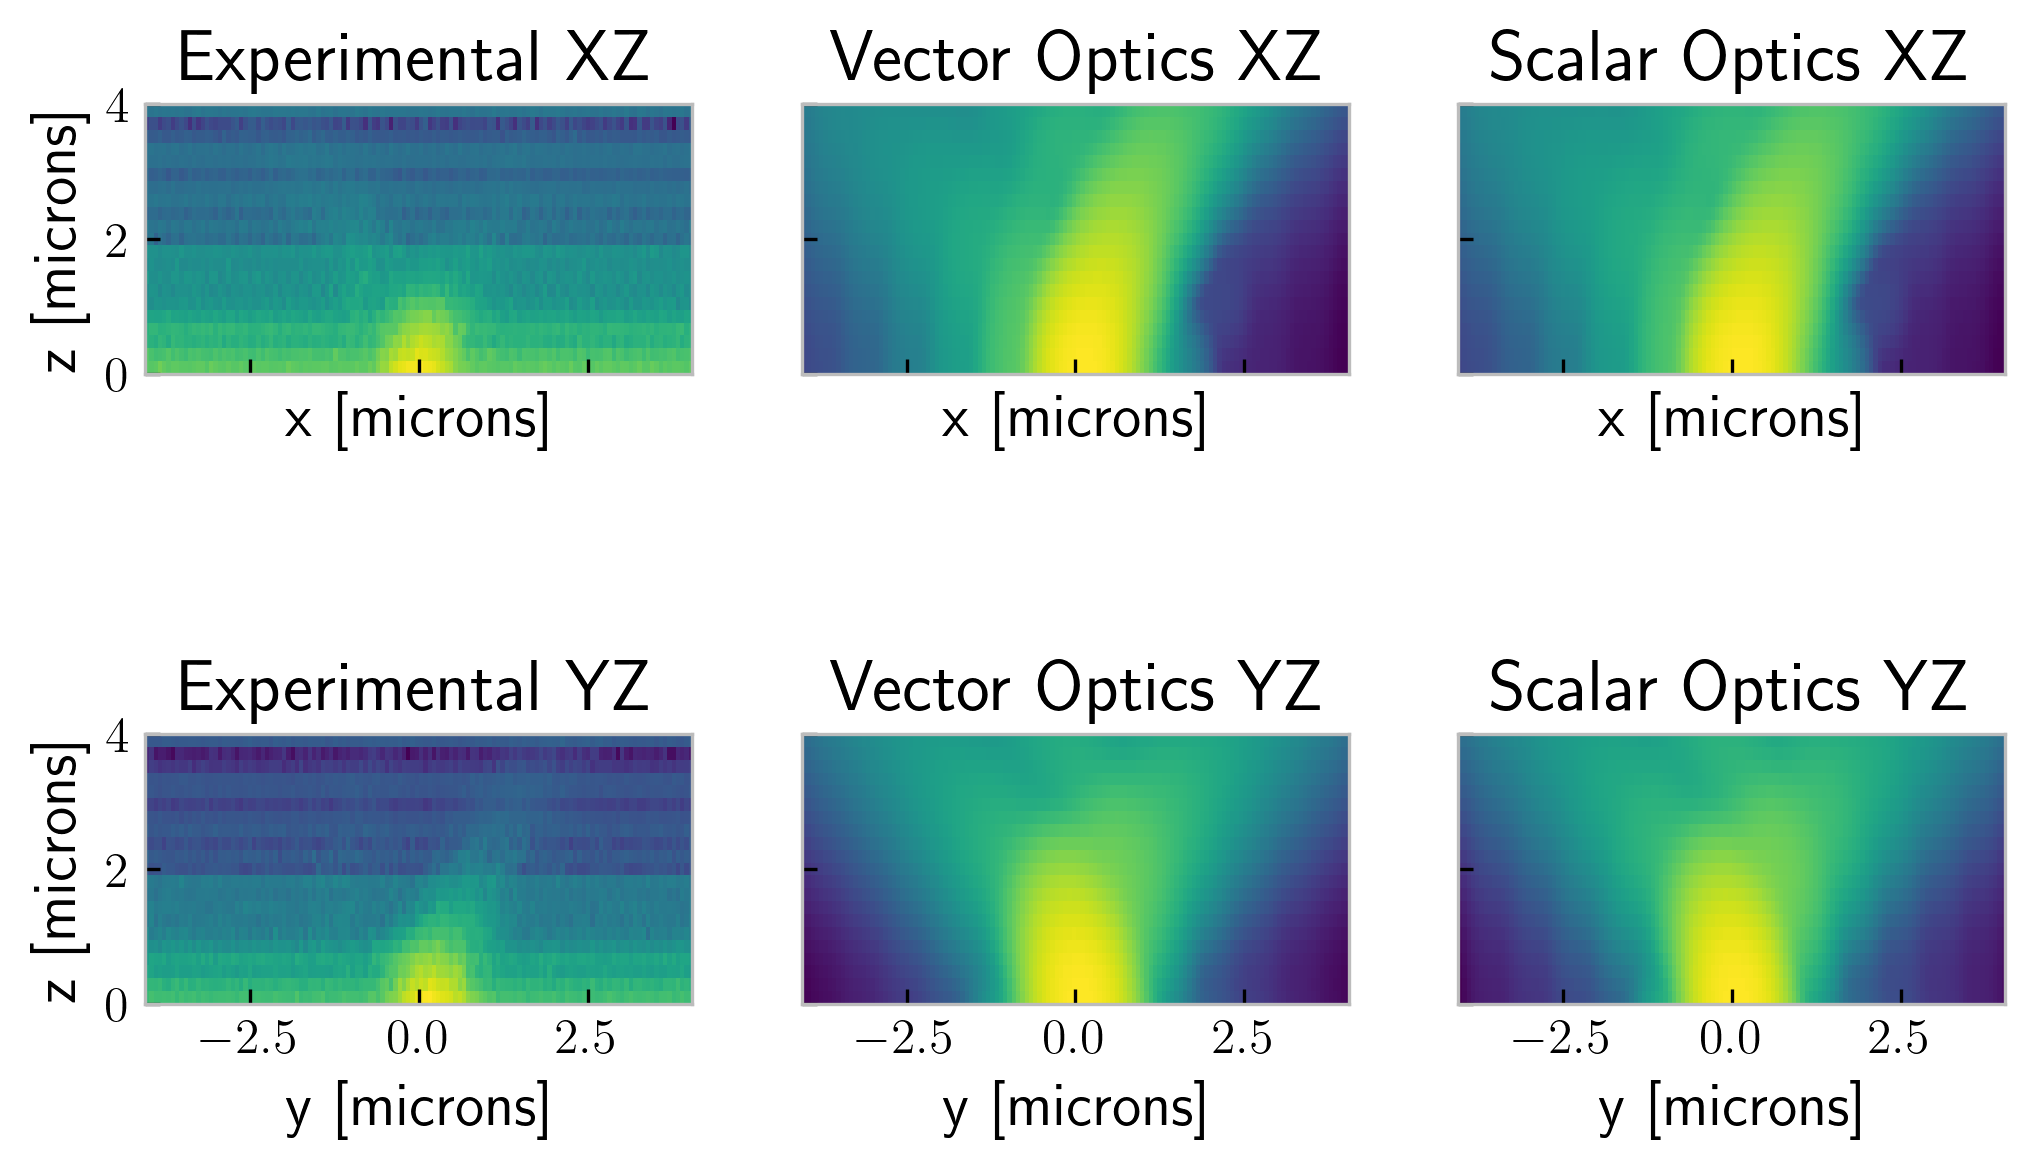

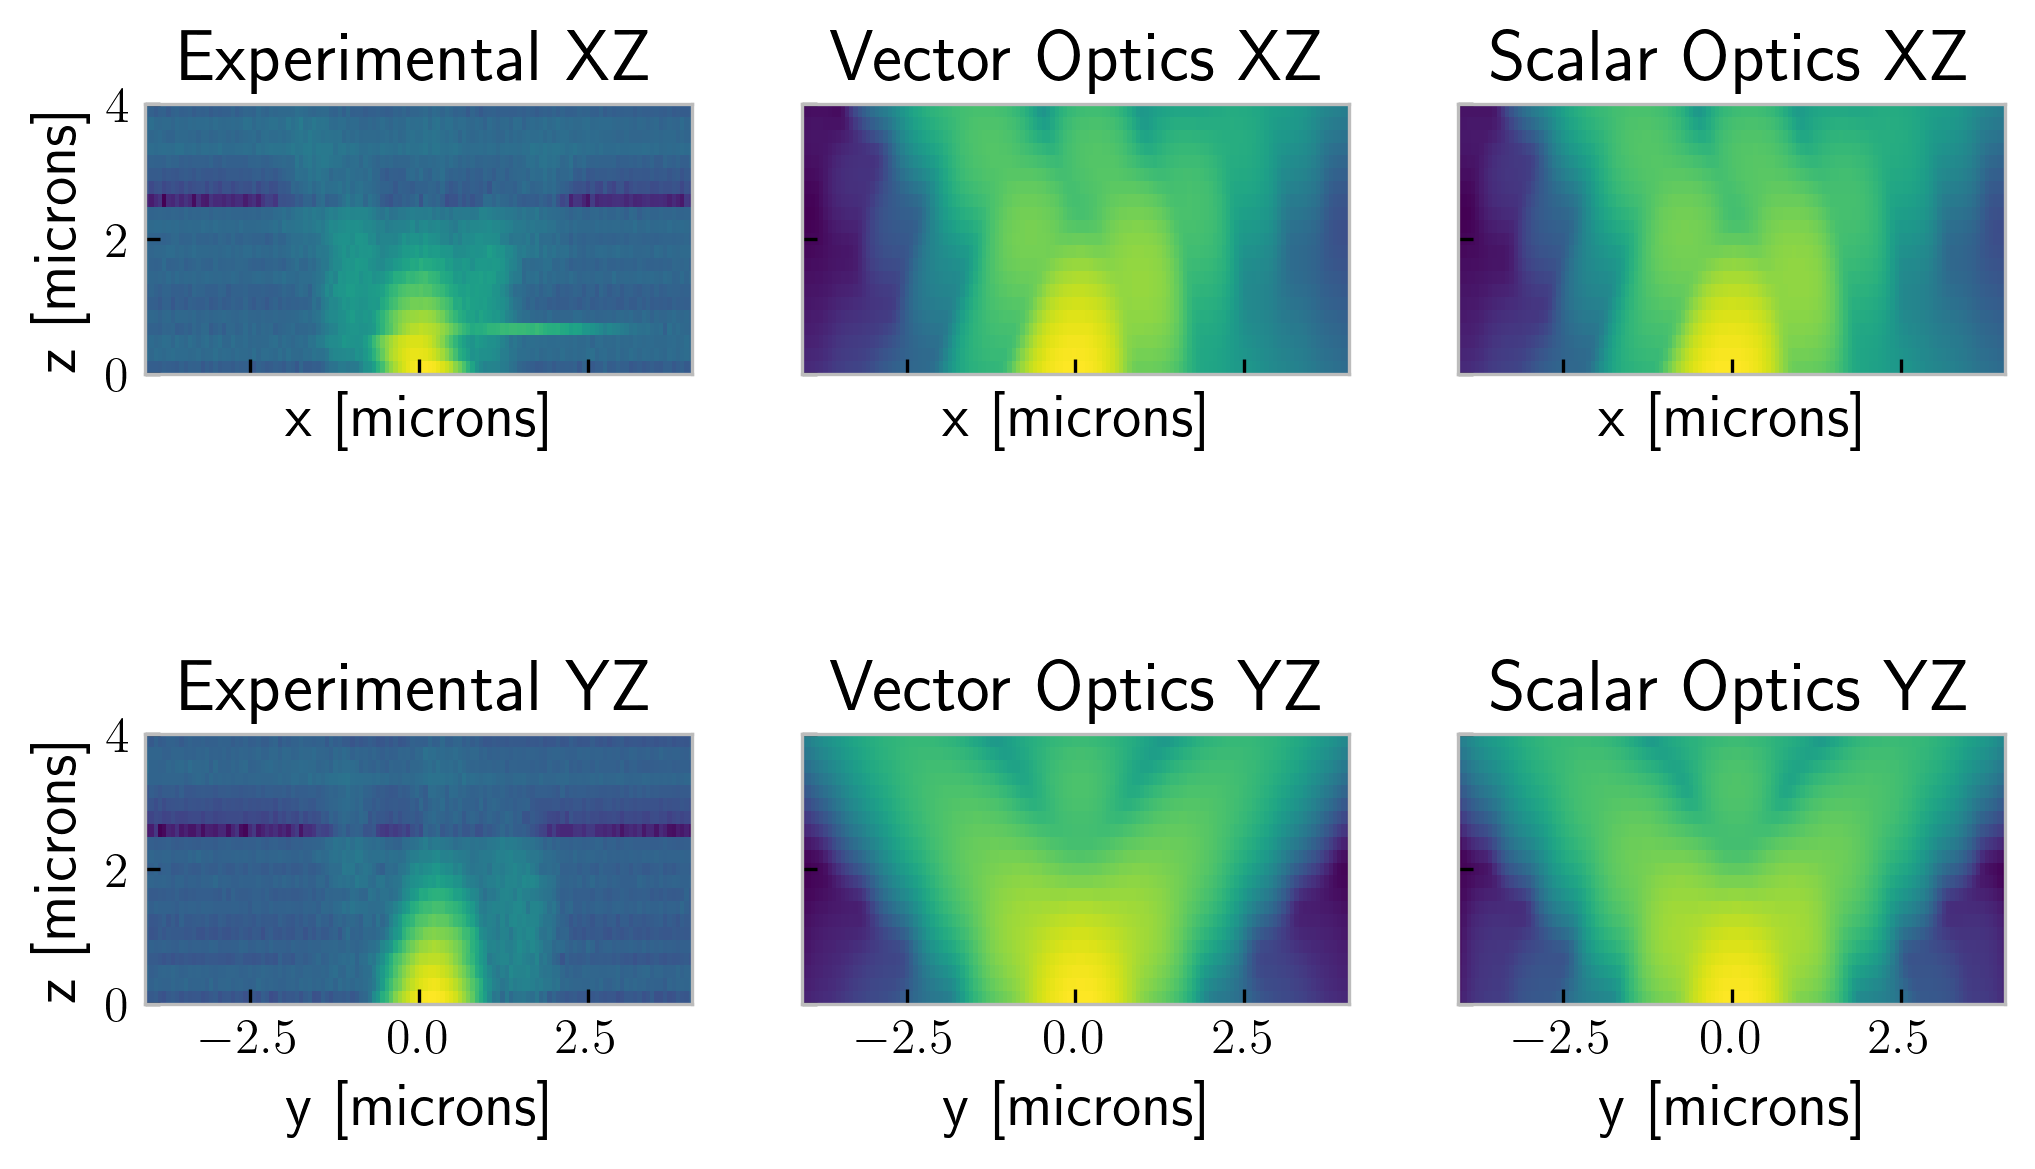

In [13]:
cross_section_plots(1)
cross_section_plots(3)
cross_section_plots(6)

In [6]:
rms_vals = np.arange(0.0, 2.2, 0.2)
z_levels = np.array([0, 1, 2, 3, 4, 5]) * 1e-3

num_samples = 100

r_vals = np.zeros((num_samples, len(rms_vals), len(z_levels)))

for i in tqdm(range(num_samples)):
    raw_aberration = generate_johnson_aberration(1.0, alpha)
    for j, rms in enumerate(rms_vals):
        
        for k, z in enumerate(z_levels):
            aberration = rescale_aberration(raw_aberration, rms, alpha)
            grid.z_level = z
            psf_scalar = microscope.compute_PSF(grid, aberration, "scalar")[2].flatten()
            psf_vector = microscope.compute_PSF_jax(grid, aberration)[2].flatten()
            r_vals[i, j, k] = np.corrcoef(psf_scalar, psf_vector)[0][1]
    

100%|██████████| 100/100 [02:37<00:00,  1.57s/it]


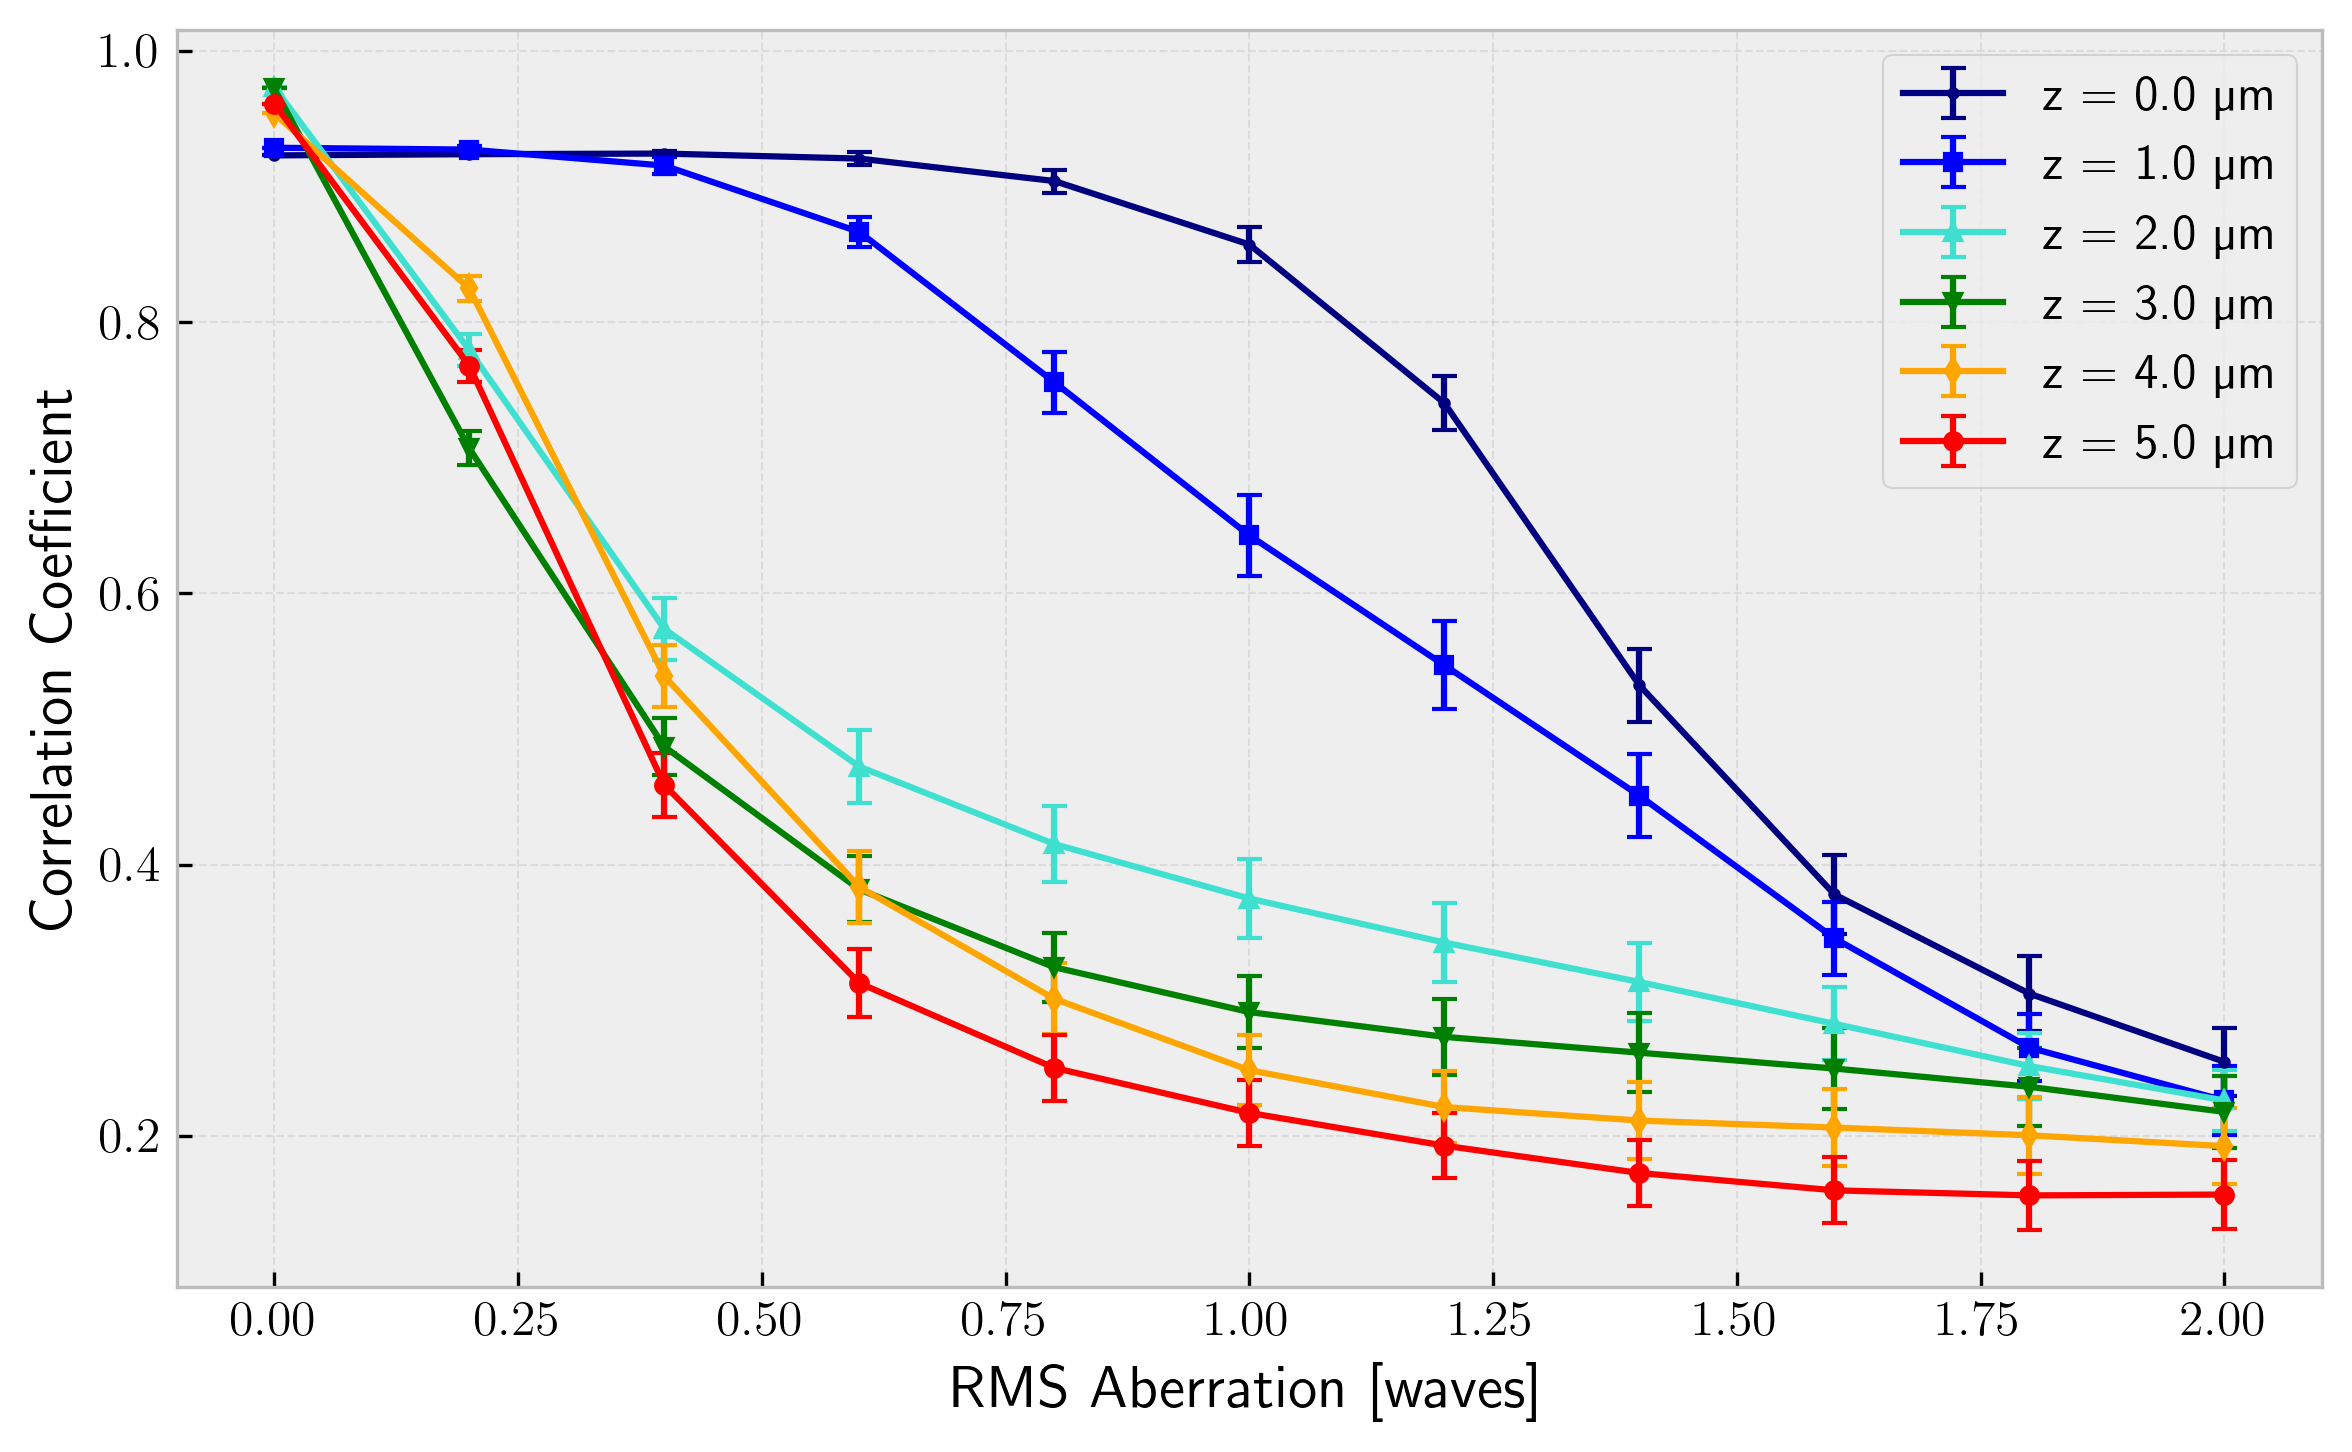

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# r_vals shape: (num_samples, len(rms_vals), len(z_levels))
r_mean = np.mean(r_vals, axis=0)              # shape: (len(rms_vals), len(z_levels))
r_sem  = np.std(r_vals, axis=0, ddof=1) / np.sqrt(r_vals.shape[0])

fig, ax = plt.subplots(dpi=300, figsize = (8, 5))

colors = ["navy", "blue", "turquoise", "green", "orange", "red"]
markers = [".", "s", "^", "v", "d", "o"]

for k, z in enumerate(z_levels):
    label = f"z = {z * 1e3:.1f} µm"

    ax.errorbar(
        rms_vals,
        r_mean[:, k],
        yerr=r_sem[:, k],
        label=label,
        color=colors[k % len(colors)],
        marker=markers[k % len(markers)],
        capsize=3,
        linewidth=1.5,
        markersize=4,
    )

ax.set_xlabel("RMS Aberration [waves]")
ax.set_ylabel("Correlation Coefficient")
ax.legend()
#ax.set_ylim(0.999, 1)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

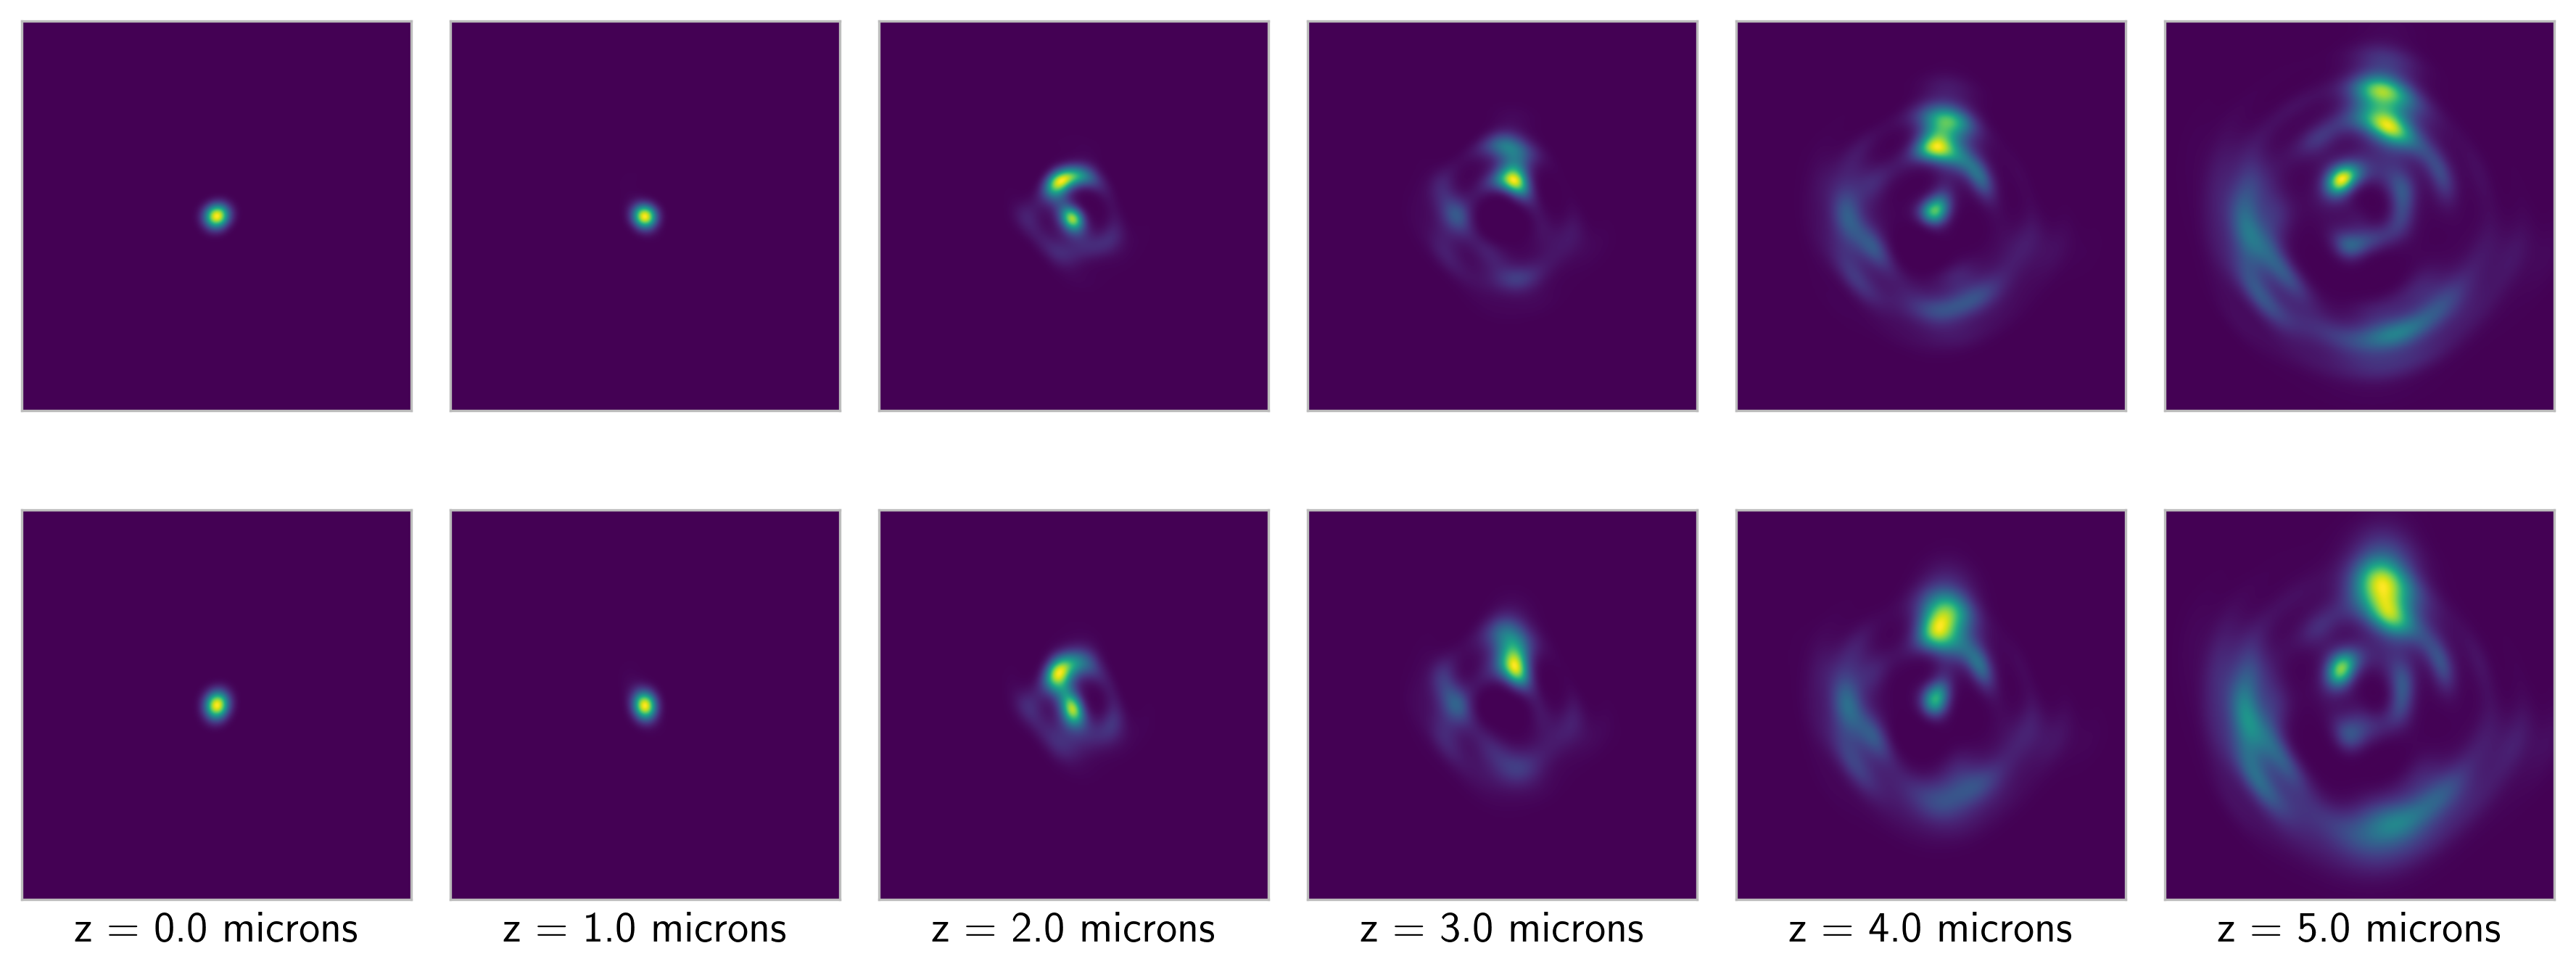

In [36]:
raw_aberration = generate_johnson_aberration(1.0, alpha)
rms = .5
aberration = rescale_aberration(raw_aberration, rms, alpha)

fig, axs = plt.subplots(2, 6, layout = "tight", figsize = (12, 6))
for i, z in enumerate(np.array([0,1,2,3,4,5]) * 1e-3):
    grid.z_level = z

    scalar = microscope.compute_PSF(grid, aberration, "scalar")[2]
    vector = microscope.compute_PSF(grid, aberration, "vector")[2]

    vmax = max(np.max(scalar), np.max(vector))
    vmin = max(np.min(scalar), np.min(vector))

    axs[0, i].imshow(scalar)#, vmin = vmin, vmax = vmax)
    axs[1,i].imshow(vector)#, vmin = vmin, vmax = vmax)
    axs[0,i].grid(False)
    axs[1,i].grid(False)
    axs[0,i].set_xticks([])
    axs[1,i].set_xticks([])

    axs[0,i].set_yticks([])
    axs[1,i].set_yticks([])

    axs[1, i].set_xlabel(f"z = {z * 1e3} microns")

